[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


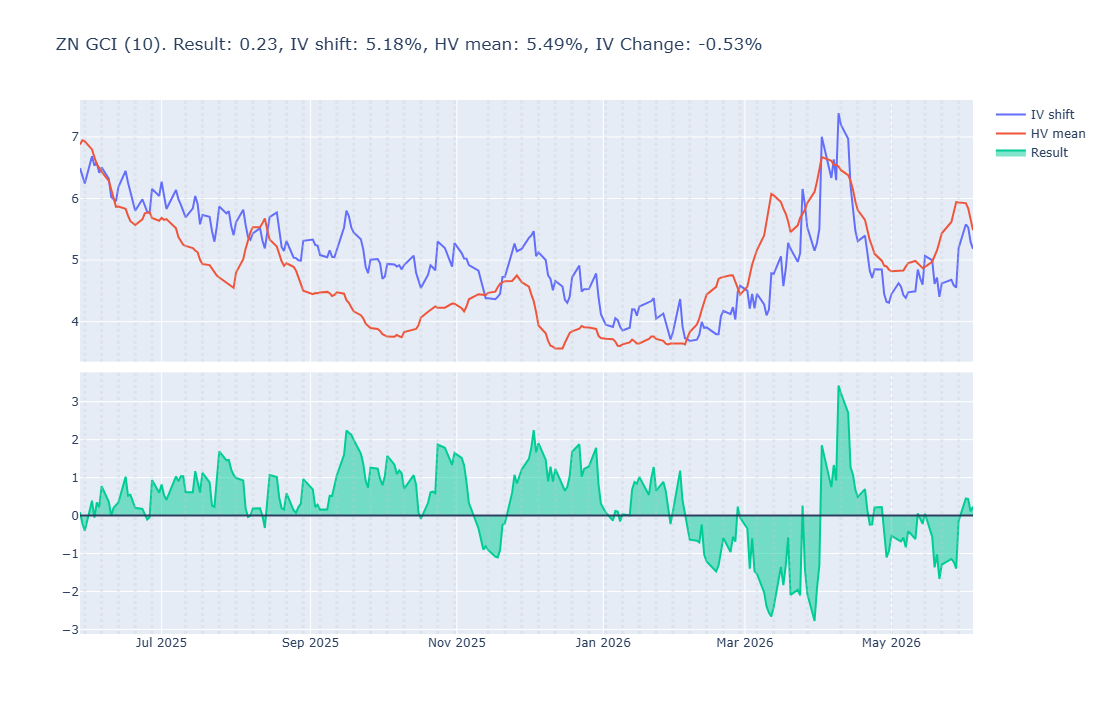

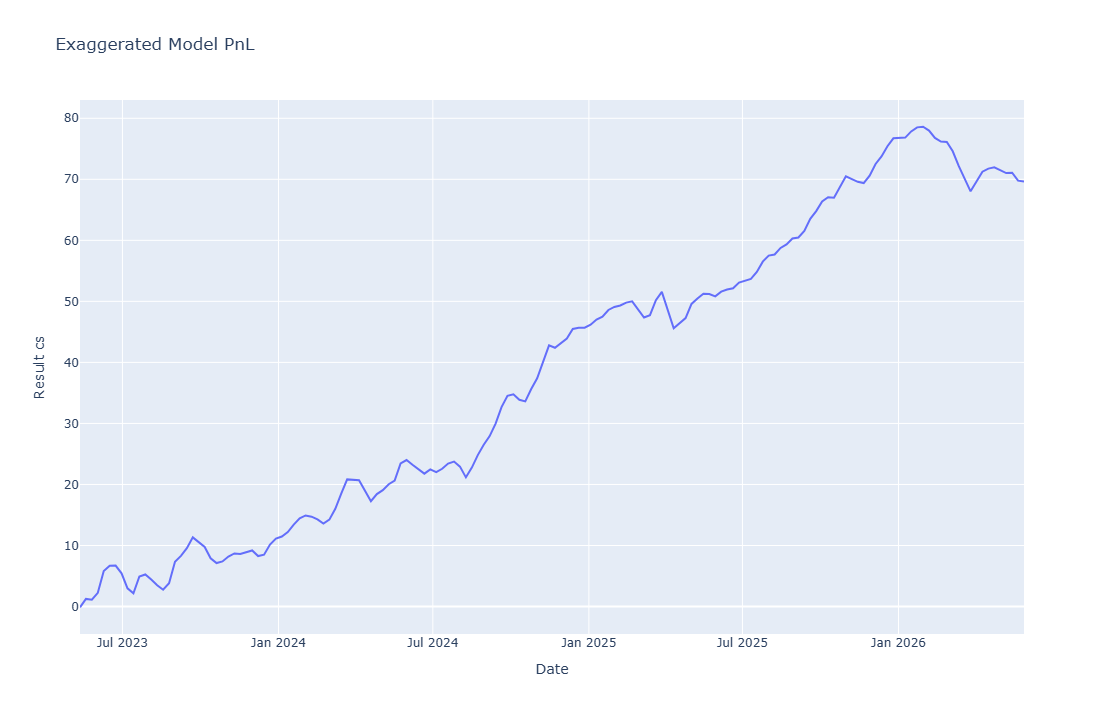

In [3]:
import yfinance as yf
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import sys
sys.path.append('..')
from utils.black76 import *
from utils.my_models import *

fig_hv22_10, hv_df_10_fig, cur_hv_10, cur_fut_10, df_yahoo_10, cur_iv_10, merged_df_10, hv_df_10 = hv_iv_fig(symbol='ZN=F', move_mult=16)

regime_10 = hv_df_10['EmergencyRegime'].iloc[-1]
alarm = regime_10 == 1
color = 'red' if alarm else 'green'

regime_10_style = {
'width': '40px',
'height': '40px',
'borderRadius': '50%',
'backgroundColor': color,
'display': 'inline-block',
'marginLeft': '10px',
'boxShadow': f'0 0 20px {color}'
}

regime_fig = px.line(
hv_df_10,
x='Date',
y='EmergencyRegime',
width=1500,
height=700,
title='Emergency Regime'
)

df_plot = merged_df_10[-252:].copy()
df_plot['Date'] = pd.to_datetime(df_plot['Date'])

# все пятницы
fridays = df_plot.loc[df_plot['Date'].dt.weekday == 4, 'Date']

gci_fig = make_subplots(
rows=2,
cols=1,
shared_xaxes=True,
row_heights=[0.5, 0.5],
vertical_spacing=0.02
)

gci_fig.update_layout(
title=f'ZN GCI (10). Result: {round(df_plot["Result"].iloc[-1], 2)}, IV shift: {round(df_plot["IV shift"].iloc[-1], 2)}%, HV mean: {round(df_plot["HV mean"].iloc[-1], 2)}%, IV Change: {round(df_plot["IV Change"].iloc[-1], 2)}%',
width=1500,
height=700,
)

# верхний график
gci_fig.add_trace(
go.Scatter(
    x=df_plot['Date'],
    y=df_plot['IV shift'],
    mode='lines',
    name='IV shift'
),
row=1, col=1
)

gci_fig.add_trace(
go.Scatter(
    x=df_plot['Date'],
    y=df_plot['HV mean'],
    mode='lines',
    name='HV mean'
),
row=1, col=1
)

# нижняя положительная заливка
gci_fig.add_trace(
go.Scatter(
    x=df_plot['Date'],
    y=df_plot['Result'],
    fill='tozeroy',
    mode='lines',
    name='Result'
),
row=2, col=1
)

gci_fig.add_hline(y=0, row=2, col=1)

for d in fridays:
    gci_fig.add_vline(
        x=d,
        line_width=3,
        line_dash='dot',
        line_color='rgba(200,200,200,0.25)',
        # row=2,
        # col=1
    )

gci_fig.show()
gci_fig.write_html('../charts/zn_iv_vs_hv.html')

merged_df_10_2 = merged_df_10[-750:]
df_fridays = merged_df_10_2.loc[merged_df_10_2['Date'].dt.weekday == 4].copy()
df_fridays['Result cs'] = df_fridays['Result'].cumsum()

df_fridays_fig = px.line(
df_fridays,
x='Date',
y='Result cs',
width=1500,
height=700,
title='Exaggerated Model PnL'
)

df_fridays_fig.show()
df_fridays_fig.write_html('../charts/model_pnl.html')